In [1]:
import pandas as pd



In [2]:
df = pd.read_csv('nifty.csv')
print(df.head())

         Date      Open      High       Low     Close   Shares Traded   \
0  15-MAY-2026  23731.40  23839.30  23610.30  23643.50       408864566   
1  14-MAY-2026  23530.25  23777.20  23426.55  23689.60       428735424   
2  13-MAY-2026  23362.45  23582.95  23262.55  23412.60       415359044   
3  12-MAY-2026  23722.60  23757.55  23348.40  23379.55       447518189   
4  11-MAY-2026  23970.10  23997.45  23799.10  23815.85       390108343   

   Turnover (₹ Cr)  
0         35052.32  
1         38828.33  
2         33693.48  
3         36200.59  
4         37404.28  


In [13]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date').reset_index(drop=True)

print(df.isnull().sum())

Date               0
Open               0
High               0
Low                0
Close              0
Shares Traded      0
Turnover (₹ Cr)    0
dtype: int64


C:\Users\MSI\AppData\Local\Temp\ipykernel_35544\2592937255.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [14]:
df.drop_duplicates(subset=['Date'], inplace=True)

df = df[(df['Open'] > 0) & (df['Close'] > 0)]

C:\Users\MSI\AppData\Local\Temp\ipykernel_35544\3439383484.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.tail(15), x=df.tail(15)['Date'].dt.strftime('%d-%b'), y='Turnover (₹ Cr)', ax=axes[1, 0], palette='viridis')


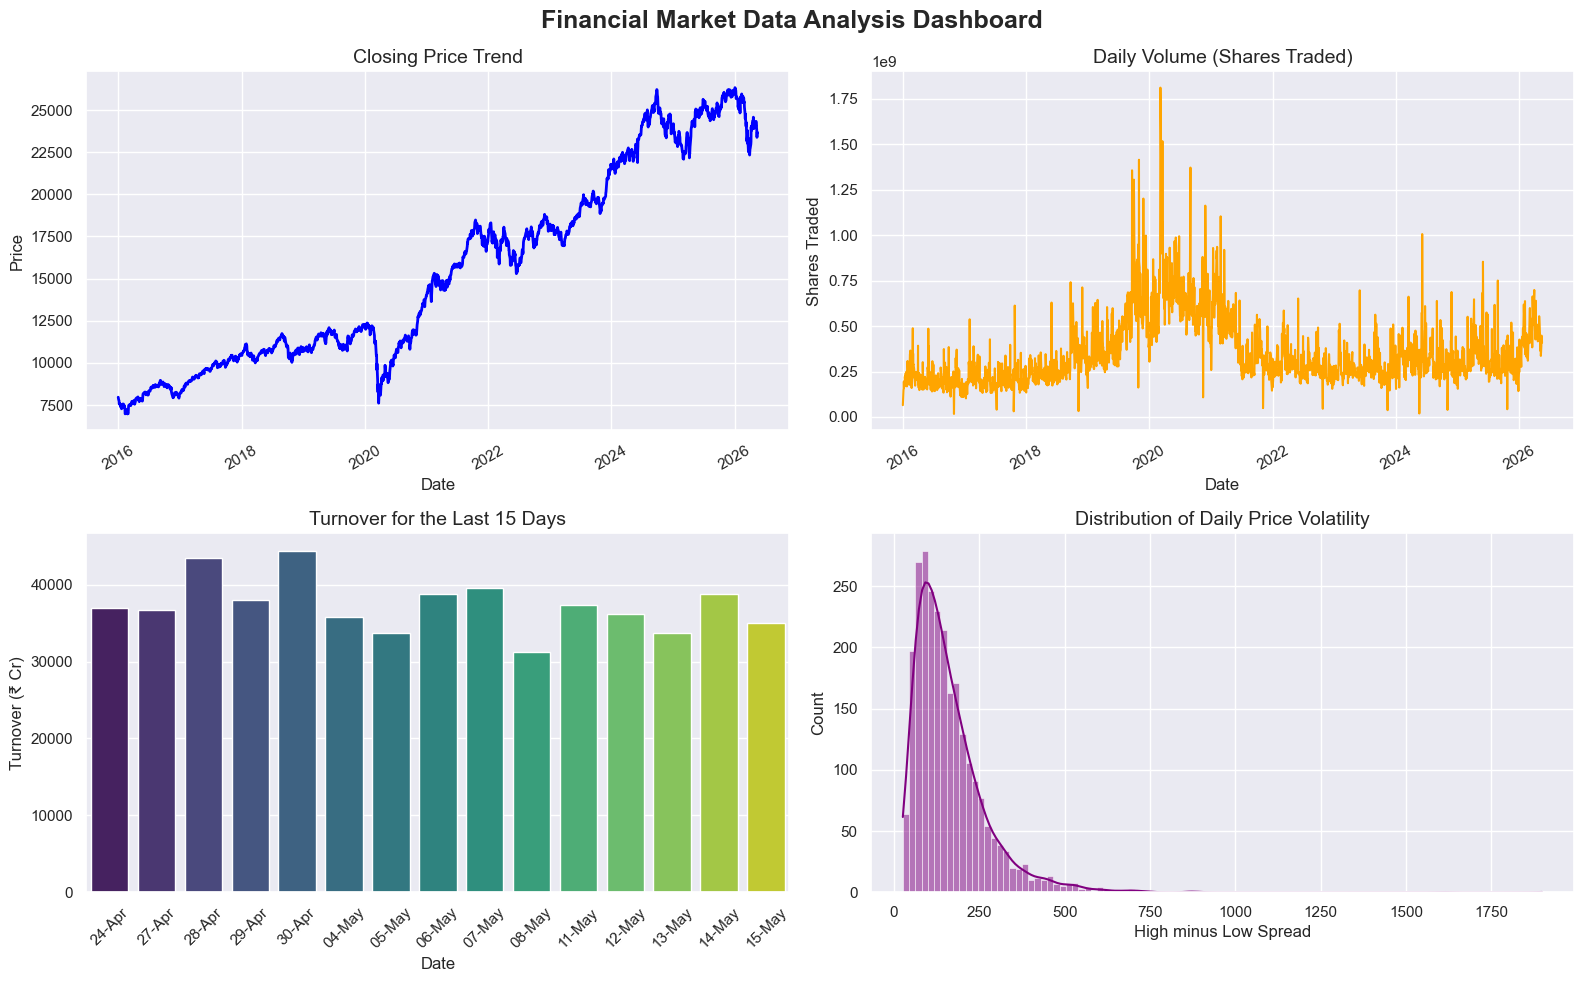

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Financial Market Data Analysis Dashboard', fontsize=18, fontweight='bold')

# Chart 1: Closing Price Trend over Time
sns.lineplot(data=df, x='Date', y='Close', ax=axes[0, 0], color='blue', linewidth=2)
axes[0, 0].set_title('Closing Price Trend', fontsize=14)
axes[0, 0].set_ylabel('Price')
axes[0, 0].tick_params(axis='x', rotation=30)

# Chart 2: Trading Volume (Shares Traded)
sns.lineplot(data=df, x='Date', y='Shares Traded', ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Daily Volume (Shares Traded)', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=30)

# Chart 3: Market Turnover (₹ Cr)
sns.barplot(data=df.tail(15), x=df.tail(15)['Date'].dt.strftime('%d-%b'), y='Turnover (₹ Cr)', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Turnover for the Last 15 Days', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)

# Chart 4: Daily Volatility (High vs Low spread)
df['Daily_Spread'] = df['High'] - df['Low']
sns.histplot(data=df, x='Daily_Spread', ax=axes[1, 1], kde=True, color='purple')
axes[1, 1].set_title('Distribution of Daily Price Volatility', fontsize=14)
axes[1, 1].set_xlabel('High minus Low Spread')

plt.tight_layout()
plt.show()

In [19]:
plt.savefig('market_analysis_dashboard.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>